#Manufacturing Supply Chain Analysis

In [2]:
# ────────────────────────────────────────────────────────────────
# CELL 1 — IMPORTS
# ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
 
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# CELL 2 — GENERATE DATASET

In [3]:
np.random.seed(42)
n = 500
 
product_categories = ['Raw Material', 'Semi-Finished', 'Finished Goods', 'Spare Parts', 'Packaging']
suppliers          = ['Tata Steel', 'JSW Steel', 'Hindalco', 'SAIL', 'Vedanta']
plants             = ['Katni Plant', 'Raipur Plant', 'Nagpur Plant', 'Bhopal Plant', 'Indore Plant']
transport_modes    = ['Road', 'Rail', 'Air', 'Courier']
warehouses         = ['WH-North', 'WH-South', 'WH-East', 'WH-West', 'WH-Central']
inspection_status  = ['Pass', 'Fail', 'Pending']
order_priority     = ['Low', 'Medium', 'High', 'Critical']
 
df = pd.DataFrame({
    'Product Category'       : np.random.choice(product_categories, n),
    'SKU'                    : ['SKU' + str(i).zfill(4) for i in np.random.randint(1, 201, n)],
    'Supplier Name'          : np.random.choice(suppliers, n),
    'Plant Location'         : np.random.choice(plants, n),
    'Warehouse'              : np.random.choice(warehouses, n),
    'Transport Mode'         : np.random.choice(transport_modes, n),
    'Order Priority'         : np.random.choice(order_priority, n, p=[0.2, 0.4, 0.3, 0.1]),
    'Order Quantity'         : np.random.randint(50, 1000, n),
    'Unit Price'             : np.random.uniform(500, 50000, n).round(2),
    'Revenue Generated'      : np.random.uniform(50000, 2000000, n).round(2),
    'Manufacturing Cost'     : np.random.uniform(10000, 800000, n).round(2),
    'Shipping Cost'          : np.random.uniform(2000, 80000, n).round(2),
    'Storage Cost'           : np.random.uniform(1000, 30000, n).round(2),
    'Stock Level'            : np.random.randint(0, 2000, n),
    'Reorder Point'          : np.random.randint(50, 300, n),
    'Lead Time (Days)'       : np.random.randint(2, 45, n),
    'Manufacturing Lead Time': np.random.randint(1, 20, n),
    'Shipping Time (Days)'   : np.random.randint(1, 15, n),
    'Production Volume'      : np.random.randint(100, 5000, n),
    'Defect Rate'            : np.random.uniform(0.001, 0.12, n).round(4),
    'Inspection Status'      : np.random.choice(inspection_status, n, p=[0.65, 0.20, 0.15]),
    'On Time Delivery'       : np.random.choice(['Yes', 'No'], n, p=[0.72, 0.28]),
    'Return Rate'            : np.random.uniform(0.001, 0.08, n).round(4),
    'Customer Satisfaction'  : np.random.uniform(2.5, 5.0, n).round(1),
    'Order Date'             : pd.date_range('2023-01-01', periods=n, freq='16h'),
})
 
print(f"📦 Dataset Shape  : {df.shape}")
print(f"📋 Columns        : {list(df.columns)}")
print(f"\n▸ First 5 rows:")
print(df.head())

📦 Dataset Shape  : (500, 25)
📋 Columns        : ['Product Category', 'SKU', 'Supplier Name', 'Plant Location', 'Warehouse', 'Transport Mode', 'Order Priority', 'Order Quantity', 'Unit Price', 'Revenue Generated', 'Manufacturing Cost', 'Shipping Cost', 'Storage Cost', 'Stock Level', 'Reorder Point', 'Lead Time (Days)', 'Manufacturing Lead Time', 'Shipping Time (Days)', 'Production Volume', 'Defect Rate', 'Inspection Status', 'On Time Delivery', 'Return Rate', 'Customer Satisfaction', 'Order Date']

▸ First 5 rows:
  Product Category      SKU Supplier Name Plant Location Warehouse  \
0      Spare Parts  SKU0062          SAIL   Nagpur Plant   WH-East   
1        Packaging  SKU0084      Hindalco   Nagpur Plant  WH-South   
2   Finished Goods  SKU0112      Hindalco   Bhopal Plant   WH-West   
3        Packaging  SKU0086    Tata Steel   Indore Plant   WH-East   
4        Packaging  SKU0141          SAIL    Katni Plant   WH-East   

  Transport Mode Order Priority  Order Quantity  Unit Price 

# CELL 3 — DATA LOADING & FIRST LOOK

In [4]:
print("\n" + "="*55)
print("STEP 1 ▸ DATA LOADING & FIRST LOOK")
print("="*55)
 
print(f"\n▸ Shape          : {df.shape}")
print(f"▸ Columns        : {df.shape[1]}")
print(f"▸ Rows           : {df.shape[0]}")
 
print("\n▸ Data Types:")
print(df.dtypes)
 
print("\n▸ Missing Values:")
print(df.isnull().sum())
 
print("\n▸ Basic Statistics:")
print(df.describe().round(2))
 
print("\n▸ Product Category Distribution:")
print(df['Product Category'].value_counts())
 
print("\n▸ Supplier Distribution:")
print(df['Supplier Name'].value_counts())


STEP 1 ▸ DATA LOADING & FIRST LOOK

▸ Shape          : (500, 25)
▸ Columns        : 25
▸ Rows           : 500

▸ Data Types:
Product Category                      str
SKU                                   str
Supplier Name                         str
Plant Location                        str
Warehouse                             str
Transport Mode                        str
Order Priority                        str
Order Quantity                      int32
Unit Price                        float64
Revenue Generated                 float64
Manufacturing Cost                float64
Shipping Cost                     float64
Storage Cost                      float64
Stock Level                         int32
Reorder Point                       int32
Lead Time (Days)                    int32
Manufacturing Lead Time             int32
Shipping Time (Days)                int32
Production Volume                   int32
Defect Rate                       float64
Inspection Status                 

# CELL 4 — EXPLORATORY DATA ANALYSIS


STEP 2 ▸ EXPLORATORY DATA ANALYSIS


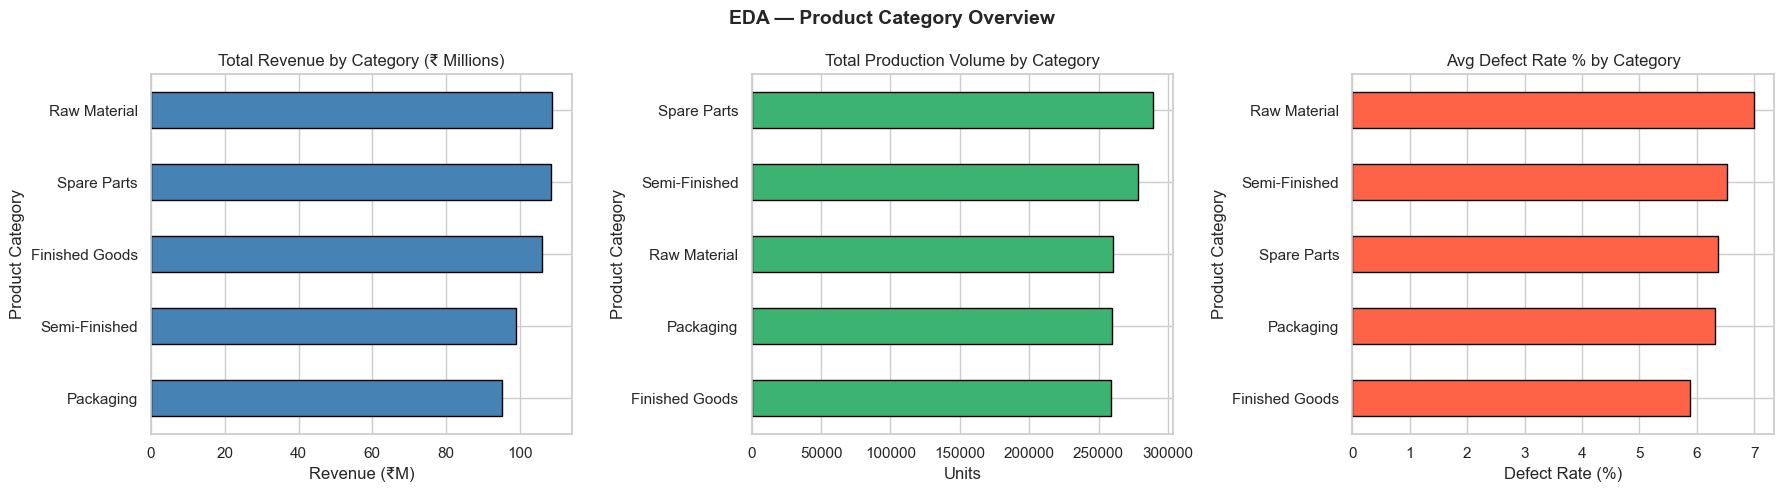

✅ Saved: 01_eda_category_overview.png


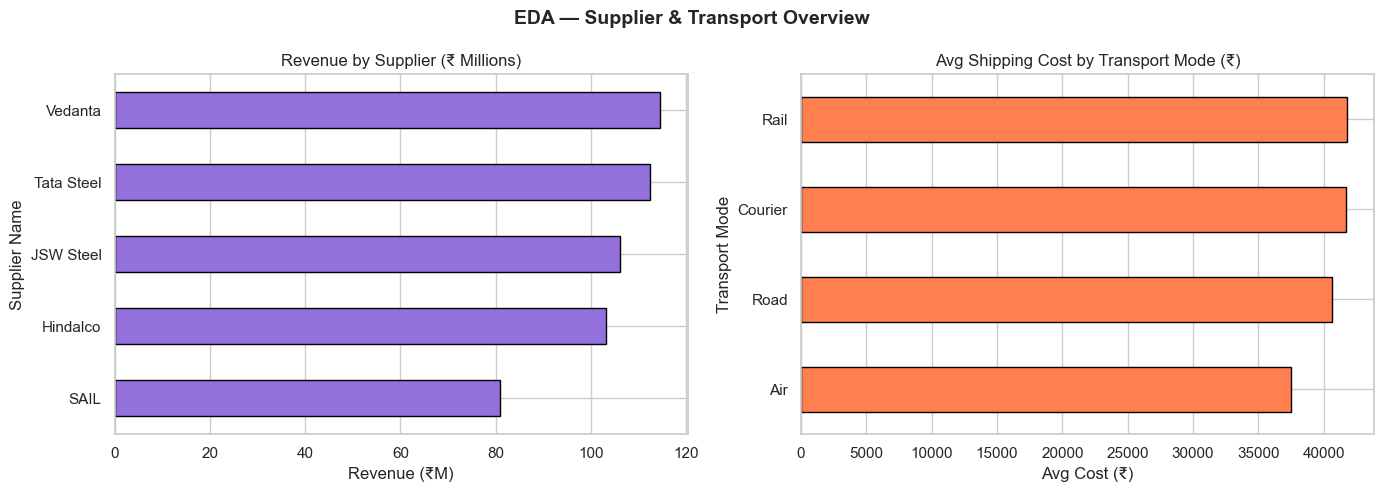

✅ Saved: 02_eda_supplier_transport.png


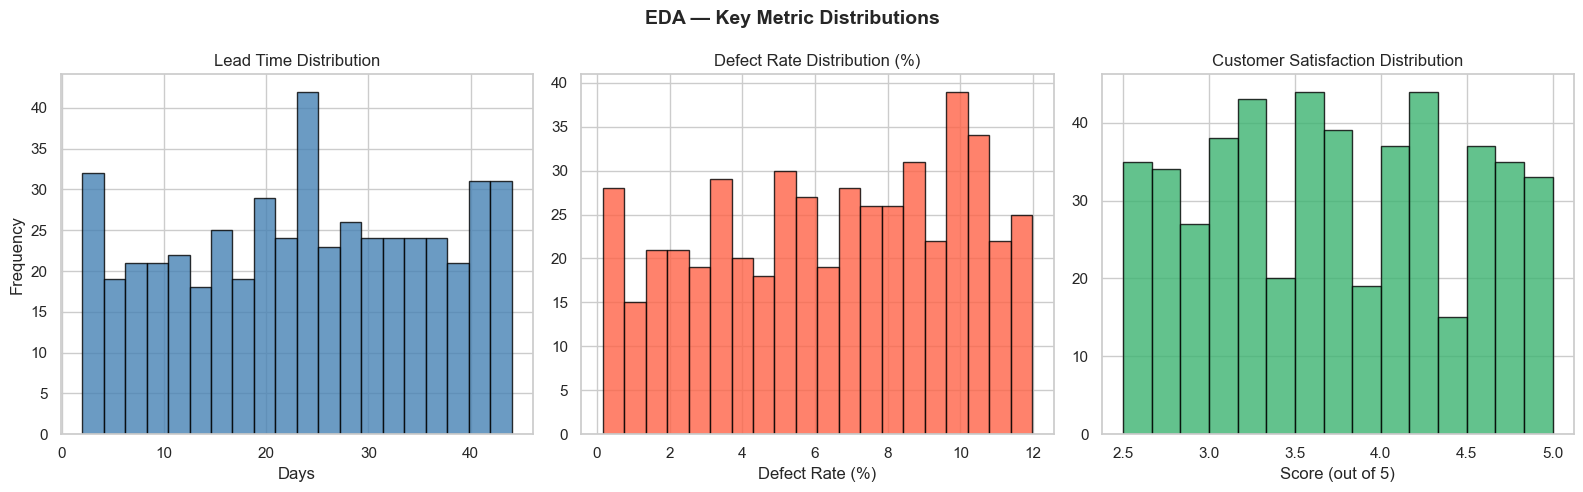

✅ Saved: 03_eda_distributions.png


In [5]:
print("\n" + "="*55)
print("STEP 2 ▸ EXPLORATORY DATA ANALYSIS")
print("="*55)
 
# --- EDA Plot 1: Revenue & Volume by Product Category ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — Product Category Overview', fontsize=14, fontweight='bold')
 
rev_cat = df.groupby('Product Category')['Revenue Generated'].sum() / 1e6
rev_cat.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Revenue by Category (₹ Millions)')
axes[0].set_xlabel('Revenue (₹M)')
 
vol_cat = df.groupby('Product Category')['Production Volume'].sum()
vol_cat.sort_values().plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Total Production Volume by Category')
axes[1].set_xlabel('Units')
 
defect_cat = df.groupby('Product Category')['Defect Rate'].mean() * 100
defect_cat.sort_values().plot(kind='barh', ax=axes[2], color='tomato', edgecolor='black')
axes[2].set_title('Avg Defect Rate % by Category')
axes[2].set_xlabel('Defect Rate (%)')
 
plt.tight_layout()
plt.savefig('01_eda_category_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_eda_category_overview.png")
 
# --- EDA Plot 2: Supplier & Transport Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Supplier & Transport Overview', fontsize=14, fontweight='bold')
 
sup_rev = df.groupby('Supplier Name')['Revenue Generated'].sum() / 1e6
sup_rev.sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('Revenue by Supplier (₹ Millions)')
axes[0].set_xlabel('Revenue (₹M)')
 
trans_cost = df.groupby('Transport Mode')['Shipping Cost'].mean()
trans_cost.sort_values().plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Avg Shipping Cost by Transport Mode (₹)')
axes[1].set_xlabel('Avg Cost (₹)')
 
plt.tight_layout()
plt.savefig('02_eda_supplier_transport.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_eda_supplier_transport.png")
 
# --- EDA Plot 3: Distribution plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Key Metric Distributions', fontsize=14, fontweight='bold')
 
axes[0].hist(df['Lead Time (Days)'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Lead Time Distribution')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')
 
axes[1].hist(df['Defect Rate'] * 100, bins=20, color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('Defect Rate Distribution (%)')
axes[1].set_xlabel('Defect Rate (%)')
 
axes[2].hist(df['Customer Satisfaction'], bins=15, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Customer Satisfaction Distribution')
axes[2].set_xlabel('Score (out of 5)')
 
plt.tight_layout()
plt.savefig('03_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_eda_distributions.png")

# CELL 5 — DATA CLEANING & FEATURE ENGINEERING

In [6]:
print("\n" + "="*55)
print("STEP 3 ▸ DATA CLEANING & FEATURE ENGINEERING")
print("="*55)
 
# Duplicates & nulls
print(f"▸ Duplicate rows before : {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"▸ Duplicate rows after  : {df.duplicated().sum()}")
print(f"▸ Null values           : {df.isnull().sum().sum()}")
 
# Extract date features
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Year']    = df['Order Date'].dt.year
 
# Derived KPIs
df['Total Cost']          = df['Manufacturing Cost'] + df['Shipping Cost'] + df['Storage Cost']
df['Gross Profit']        = df['Revenue Generated'] - df['Total Cost']
df['Profit Margin %']     = ((df['Gross Profit'] / df['Revenue Generated']) * 100).round(2)
df['Cost per Unit']       = (df['Total Cost'] / df['Order Quantity']).round(2)
df['Revenue per Unit']    = (df['Revenue Generated'] / df['Order Quantity']).round(2)
df['Total Lead Time']     = df['Lead Time (Days)'] + df['Manufacturing Lead Time'] + df['Shipping Time (Days)']
df['Inventory Turnover']  = (df['Production Volume'] / df['Stock Level'].replace(0, np.nan)).round(4)
df['Inventory Turnover'].fillna(0, inplace=True)
df['Delivery Efficiency'] = (df['On Time Delivery'] == 'Yes').astype(int)
 
print("\n✅ New features created:")
new_feats = ['Total Cost', 'Gross Profit', 'Profit Margin %',
             'Cost per Unit', 'Revenue per Unit', 'Total Lead Time',
             'Inventory Turnover', 'Delivery Efficiency']
print(df[new_feats].describe().round(2))
print(f"\n✅ Final dataset shape : {df.shape}")


STEP 3 ▸ DATA CLEANING & FEATURE ENGINEERING
▸ Duplicate rows before : 0
▸ Duplicate rows after  : 0
▸ Null values           : 0

✅ New features created:
       Total Cost  Gross Profit  Profit Margin %  Cost per Unit  \
count      500.00        500.00           500.00         500.00   
mean    446534.57     588253.37            17.72        1384.22   
std     235462.27     606634.73           141.66        1870.91   
min      36584.26    -793425.65         -1313.07          60.27   
25%     239212.87      68682.11            12.79         461.42   
50%     435705.27     613731.96            56.60         873.08   
75%     654517.68    1060282.16            76.75        1537.36   
max     879756.26    1884056.93            97.36       16095.07   

       Revenue per Unit  Total Lead Time  Inventory Turnover  \
count            500.00           500.00              500.00   
mean            3267.06            41.18               10.37   
std             4102.81            13.71         

# CELL 6 — SOLVING RESEARCH QUESTIONS


STEP 4 ▸ RESEARCH QUESTIONS

📌 Q1: Revenue by Product Category (₹)
Product Category
Raw Material      ₹108,827,339
Spare Parts       ₹108,344,435
Finished Goods    ₹105,994,831
Semi-Finished      ₹98,953,897
Packaging          ₹95,273,467
Name: Revenue Generated, dtype: str

📌 Q2: Avg Defect Rate by Supplier
Supplier Name
SAIL          6.86%
Tata Steel    6.65%
Hindalco      6.42%
JSW Steel     6.40%
Vedanta       5.93%
Name: Defect Rate, dtype: str

📌 Q3: Avg Total Lead Time by Plant (Days)
Plant Location
Nagpur Plant    43.7
Raipur Plant    43.2
Bhopal Plant    41.0
Indore Plant    39.2
Katni Plant     39.0
Name: Total Lead Time, dtype: float64

📌 Q4: Avg Shipping Cost by Transport Mode (₹)
Transport Mode
Rail       ₹41,766
Courier    ₹41,723
Road       ₹40,646
Air        ₹37,480
Name: Shipping Cost, dtype: str

📌 Q5: On-Time Delivery Rate by Supplier
Supplier Name
Vedanta       76.2%
Hindalco      75.2%
Tata Steel    73.1%
SAIL          68.3%
JSW Steel     65.0%
Name: Delivery Effi

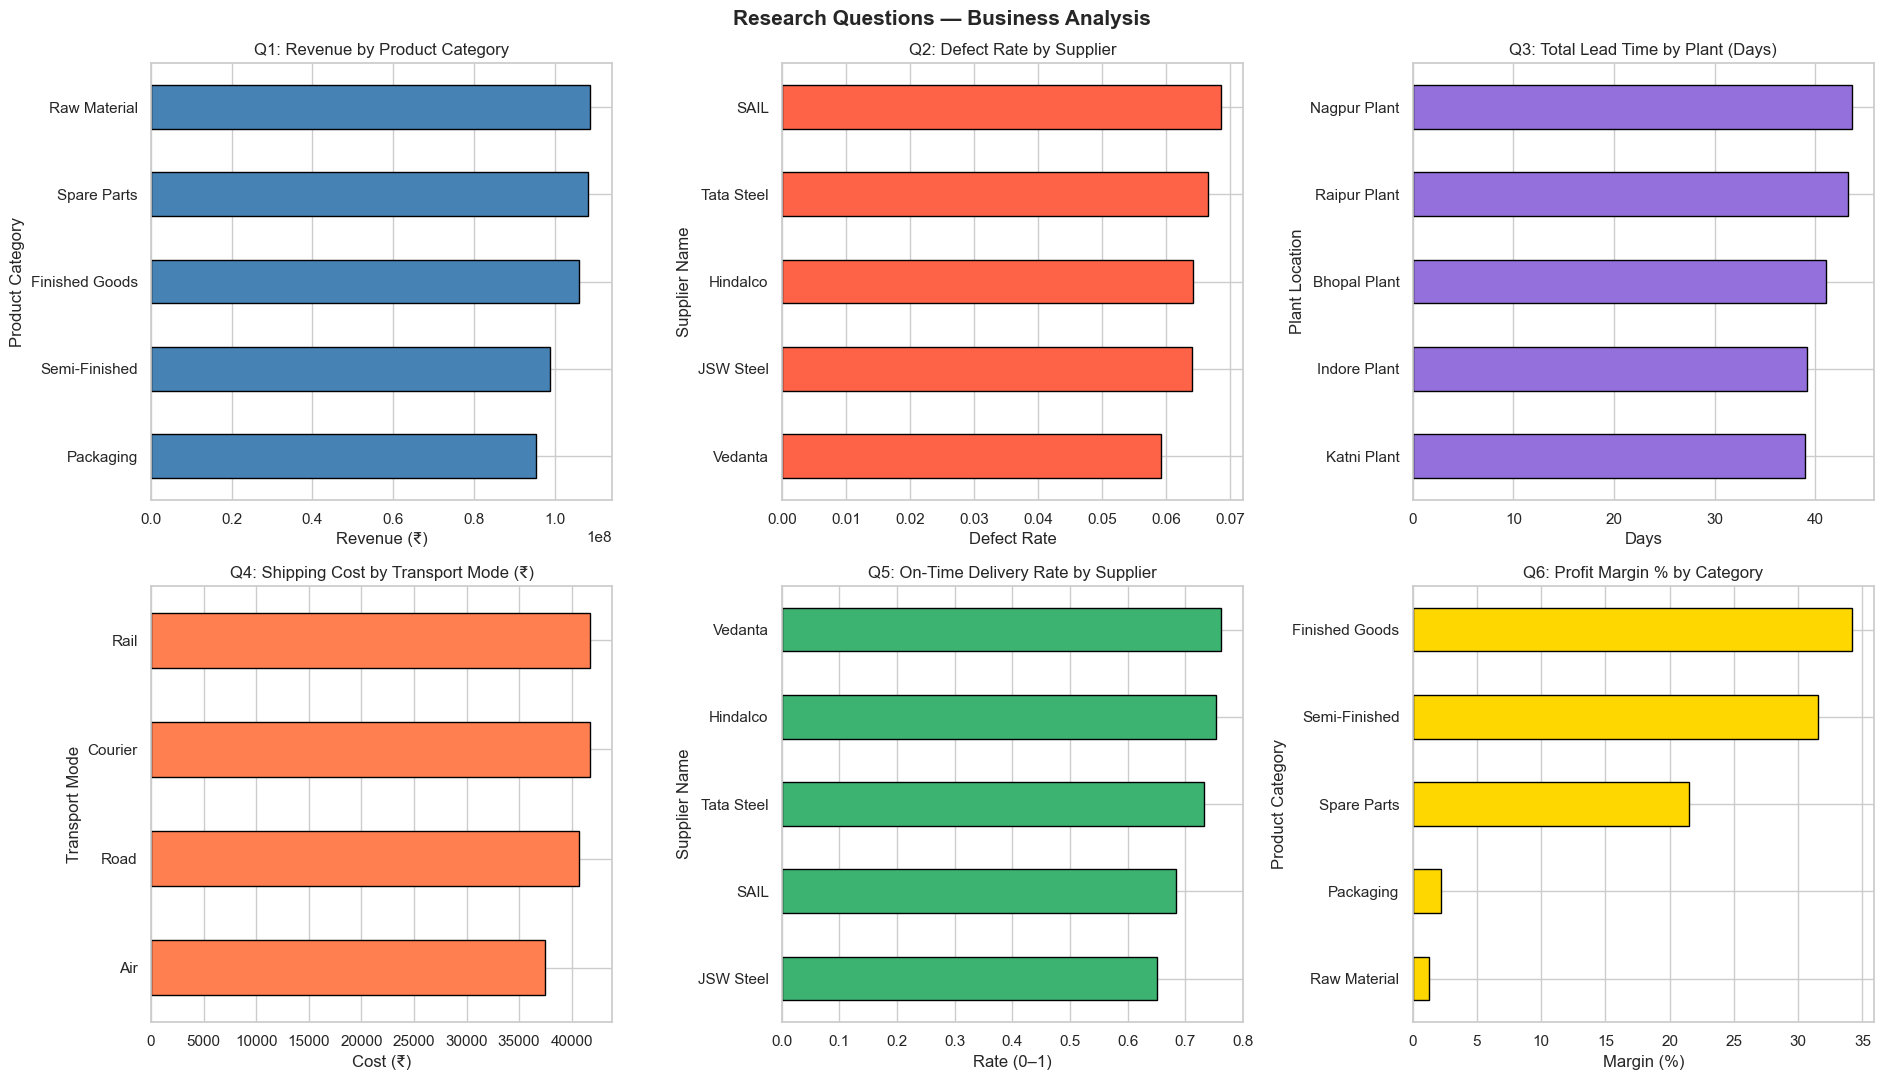

✅ Saved: 04_research_questions.png


In [7]:
print("\n" + "="*55)
print("STEP 4 ▸ RESEARCH QUESTIONS")
print("="*55)
 
# Q1: Which product category generates highest revenue?
q1 = df.groupby('Product Category')['Revenue Generated'].sum().sort_values(ascending=False)
print("\n📌 Q1: Revenue by Product Category (₹)")
print(q1.apply(lambda x: f"₹{x:,.0f}"))
 
# Q2: Which supplier has the highest avg defect rate?
q2 = df.groupby('Supplier Name')['Defect Rate'].mean().sort_values(ascending=False)
print("\n📌 Q2: Avg Defect Rate by Supplier")
print(q2.apply(lambda x: f"{x*100:.2f}%"))
 
# Q3: Which plant has the longest average lead time?
q3 = df.groupby('Plant Location')['Total Lead Time'].mean().sort_values(ascending=False)
print("\n📌 Q3: Avg Total Lead Time by Plant (Days)")
print(q3.round(1))
 
# Q4: Which transport mode is costliest?
q4 = df.groupby('Transport Mode')['Shipping Cost'].mean().sort_values(ascending=False)
print("\n📌 Q4: Avg Shipping Cost by Transport Mode (₹)")
print(q4.apply(lambda x: f"₹{x:,.0f}"))
 
# Q5: On-time delivery rate by supplier?
q5 = df.groupby('Supplier Name')['Delivery Efficiency'].mean().sort_values(ascending=False)
print("\n📌 Q5: On-Time Delivery Rate by Supplier")
print(q5.apply(lambda x: f"{x*100:.1f}%"))
 
# Q6: Avg profit margin by product category?
q6 = df.groupby('Product Category')['Profit Margin %'].mean().sort_values(ascending=False)
print("\n📌 Q6: Avg Profit Margin % by Category")
print(q6.round(2))
 
# Visualise all 6
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('Research Questions — Business Analysis', fontsize=15, fontweight='bold')
 
q1.sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Q1: Revenue by Product Category')
axes[0,0].set_xlabel('Revenue (₹)')
 
q2.sort_values().plot(kind='barh', ax=axes[0,1], color='tomato', edgecolor='black')
axes[0,1].set_title('Q2: Defect Rate by Supplier')
axes[0,1].set_xlabel('Defect Rate')
 
q3.sort_values().plot(kind='barh', ax=axes[0,2], color='mediumpurple', edgecolor='black')
axes[0,2].set_title('Q3: Total Lead Time by Plant (Days)')
axes[0,2].set_xlabel('Days')
 
q4.sort_values().plot(kind='barh', ax=axes[1,0], color='coral', edgecolor='black')
axes[1,0].set_title('Q4: Shipping Cost by Transport Mode (₹)')
axes[1,0].set_xlabel('Cost (₹)')
 
q5.sort_values().plot(kind='barh', ax=axes[1,1], color='mediumseagreen', edgecolor='black')
axes[1,1].set_title('Q5: On-Time Delivery Rate by Supplier')
axes[1,1].set_xlabel('Rate (0–1)')
 
q6.sort_values().plot(kind='barh', ax=axes[1,2], color='gold', edgecolor='black')
axes[1,2].set_title('Q6: Profit Margin % by Category')
axes[1,2].set_xlabel('Margin (%)')
 
plt.tight_layout()
plt.savefig('04_research_questions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_research_questions.png")

# CELL 7 — BOTTLENECK DETECTION


STEP 5 ▸ BOTTLENECK DETECTION
🚨 Top 10 Supply Chain Bottlenecks:
Supplier Name Plant Location  Avg_Lead_Time  Avg_Defect_Rate  Avg_Shipping_Cost  Total_Orders  OnTime_Rate  Bottleneck Score
    JSW Steel   Nagpur Plant      42.142857         0.076500       47031.252143            14     0.714286             60.82
         SAIL   Nagpur Plant      45.214286         0.070957       30194.597857            14     0.642857             60.71
     Hindalco   Nagpur Plant      41.052632         0.075563       38118.393684            19     0.736842             59.47
    JSW Steel    Katni Plant      43.263158         0.068432       42891.687368            19     0.631579             58.89
   Tata Steel   Indore Plant      43.850000         0.066330       37395.576500            20     0.600000             58.70
         SAIL   Indore Plant      37.700000         0.076195       35605.739000            20     0.750000             58.18
         SAIL   Raipur Plant      45.466667         0.06640

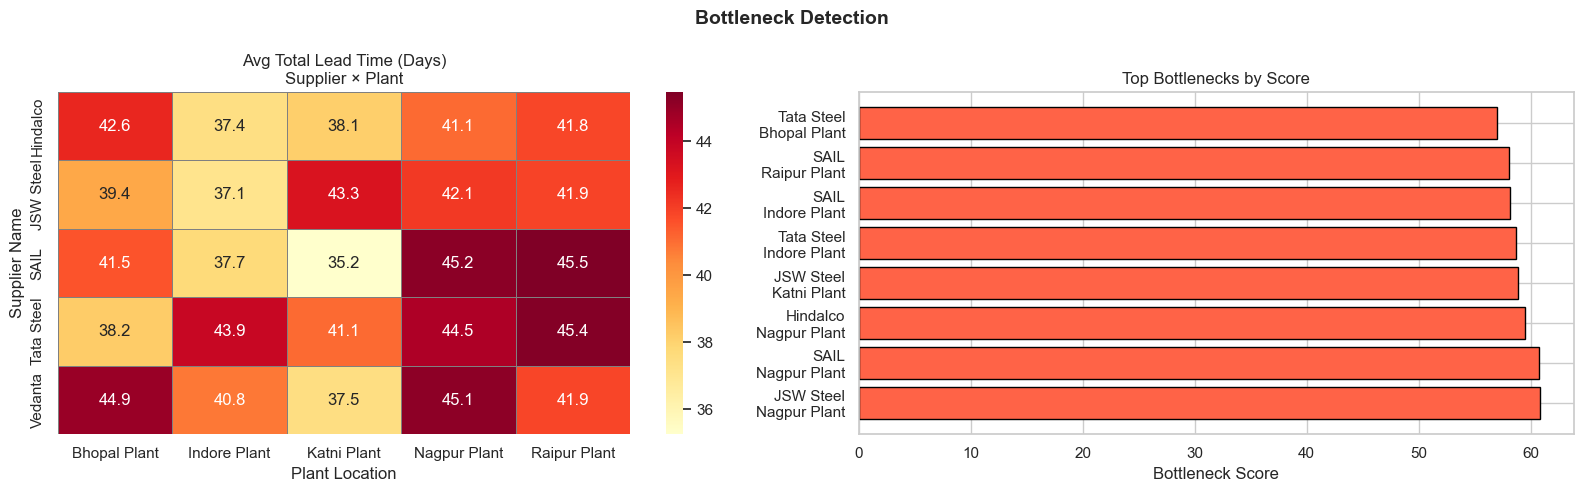

✅ Saved: 05_bottleneck_detection.png


In [8]:
print("\n" + "="*55)
print("STEP 5 ▸ BOTTLENECK DETECTION")
print("="*55)
 
bottleneck = df.groupby(['Supplier Name', 'Plant Location']).agg(
    Avg_Lead_Time    = ('Total Lead Time',   'mean'),
    Avg_Defect_Rate  = ('Defect Rate',       'mean'),
    Avg_Shipping_Cost= ('Shipping Cost',     'mean'),
    Total_Orders     = ('Order Quantity',    'count'),
    OnTime_Rate      = ('Delivery Efficiency','mean')
).reset_index()
 
# Bottleneck Score = weighted combination of lead time + defect rate + late delivery
bottleneck['Bottleneck Score'] = (
    bottleneck['Avg_Lead_Time']   * 0.4 +
    bottleneck['Avg_Defect_Rate'] * 500 +
    (1 - bottleneck['OnTime_Rate']) * 20
).round(2)
 
print("🚨 Top 10 Supply Chain Bottlenecks:")
print(bottleneck.sort_values('Bottleneck Score', ascending=False)
                .head(10).to_string(index=False))
 
# Heatmap: Lead Time by Supplier x Plant
pivot_lt = df.pivot_table(values='Total Lead Time',
                           index='Supplier Name',
                           columns='Plant Location',
                           aggfunc='mean')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Bottleneck Detection', fontsize=14, fontweight='bold')
 
sns.heatmap(pivot_lt, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray', ax=axes[0])
axes[0].set_title('Avg Total Lead Time (Days)\nSupplier × Plant')
 
# Bottleneck Score bar chart
top_bn = bottleneck.sort_values('Bottleneck Score', ascending=False).head(8)
top_bn['Label'] = top_bn['Supplier Name'] + '\n' + top_bn['Plant Location']
axes[1].barh(top_bn['Label'], top_bn['Bottleneck Score'],
             color='tomato', edgecolor='black')
axes[1].set_title('Top Bottlenecks by Score')
axes[1].set_xlabel('Bottleneck Score')
 
plt.tight_layout()
plt.savefig('05_bottleneck_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 05_bottleneck_detection.png")

 #CELL 8 — ROOT CAUSE ANALYSIS


STEP 6 ▸ ROOT CAUSE ANALYSIS


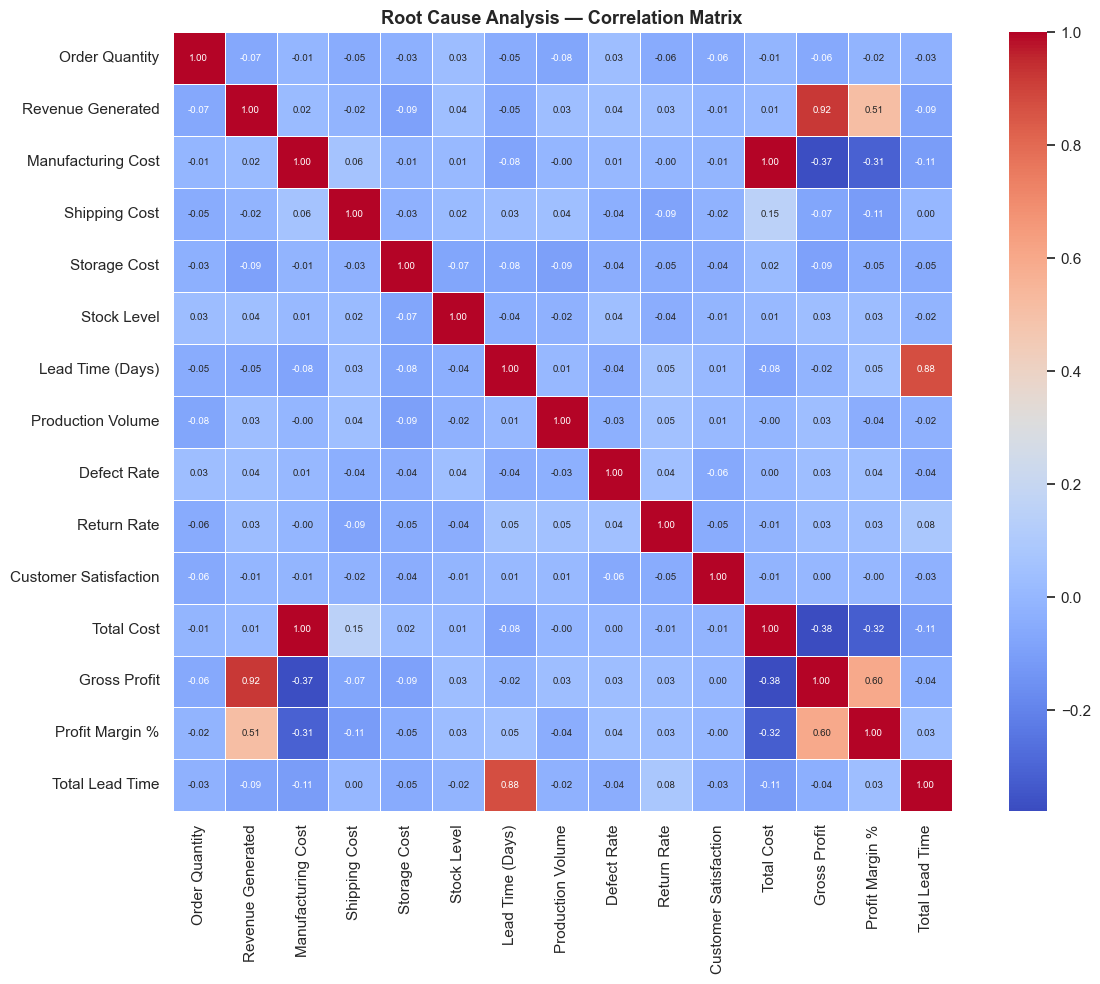

✅ Saved: 06_rca_correlation.png


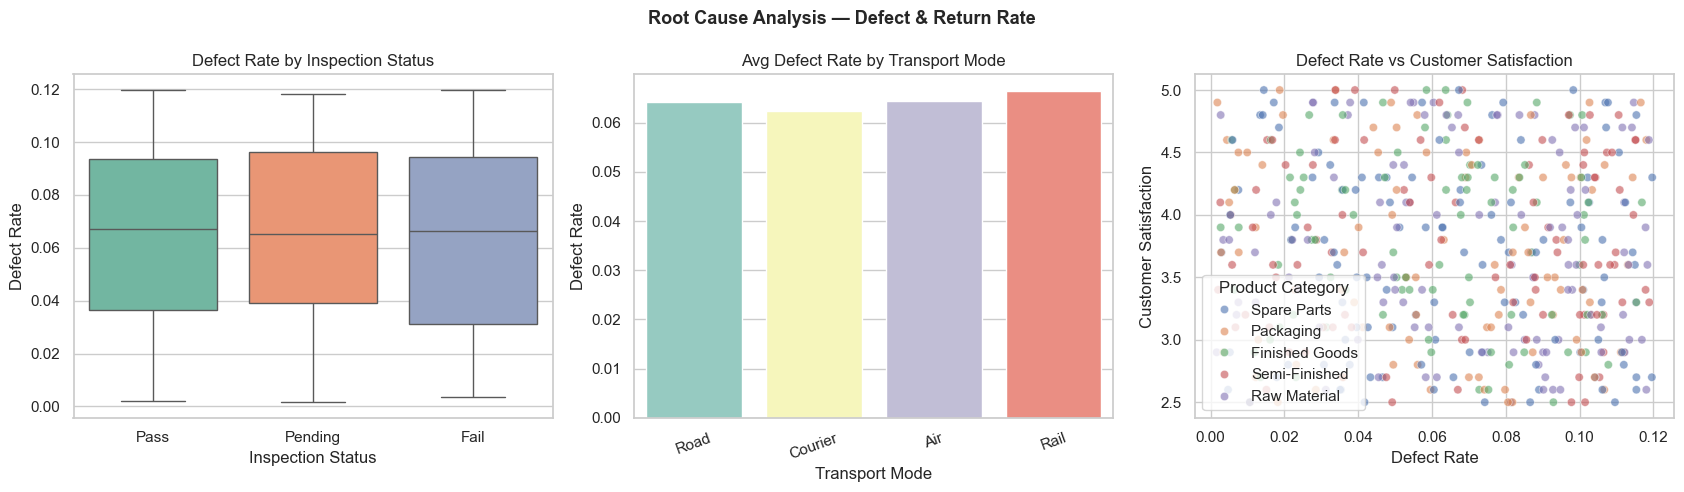

✅ Saved: 07_rca_defect_deep_dive.png


In [9]:
print("\n" + "="*55)
print("STEP 6 ▸ ROOT CAUSE ANALYSIS")
print("="*55)
 
numeric_cols = ['Order Quantity', 'Revenue Generated', 'Manufacturing Cost',
                'Shipping Cost', 'Storage Cost', 'Stock Level',
                'Lead Time (Days)', 'Production Volume', 'Defect Rate',
                'Return Rate', 'Customer Satisfaction', 'Total Cost',
                'Gross Profit', 'Profit Margin %', 'Total Lead Time']
 
corr = df[numeric_cols].corr()
 
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, annot_kws={'size': 7})
plt.title('Root Cause Analysis — Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_rca_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 06_rca_correlation.png")
 
# Defect & Return Rate deep dive
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Root Cause Analysis — Defect & Return Rate', fontsize=13, fontweight='bold')
 
sns.boxplot(data=df, x='Inspection Status', y='Defect Rate',
            palette='Set2', ax=axes[0])
axes[0].set_title('Defect Rate by Inspection Status')
 
sns.barplot(data=df, x='Transport Mode', y='Defect Rate',
            palette='Set3', ax=axes[1], ci=None)
axes[1].set_title('Avg Defect Rate by Transport Mode')
axes[1].tick_params(axis='x', rotation=20)
 
sns.scatterplot(data=df, x='Defect Rate', y='Customer Satisfaction',
                hue='Product Category', alpha=0.6, ax=axes[2])
axes[2].set_title('Defect Rate vs Customer Satisfaction')
 
plt.tight_layout()
plt.savefig('07_rca_defect_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 07_rca_defect_deep_dive.png")

# CELL 9 — TIME SERIES ANALYSIS


STEP 7 ▸ TIME SERIES ANALYSIS


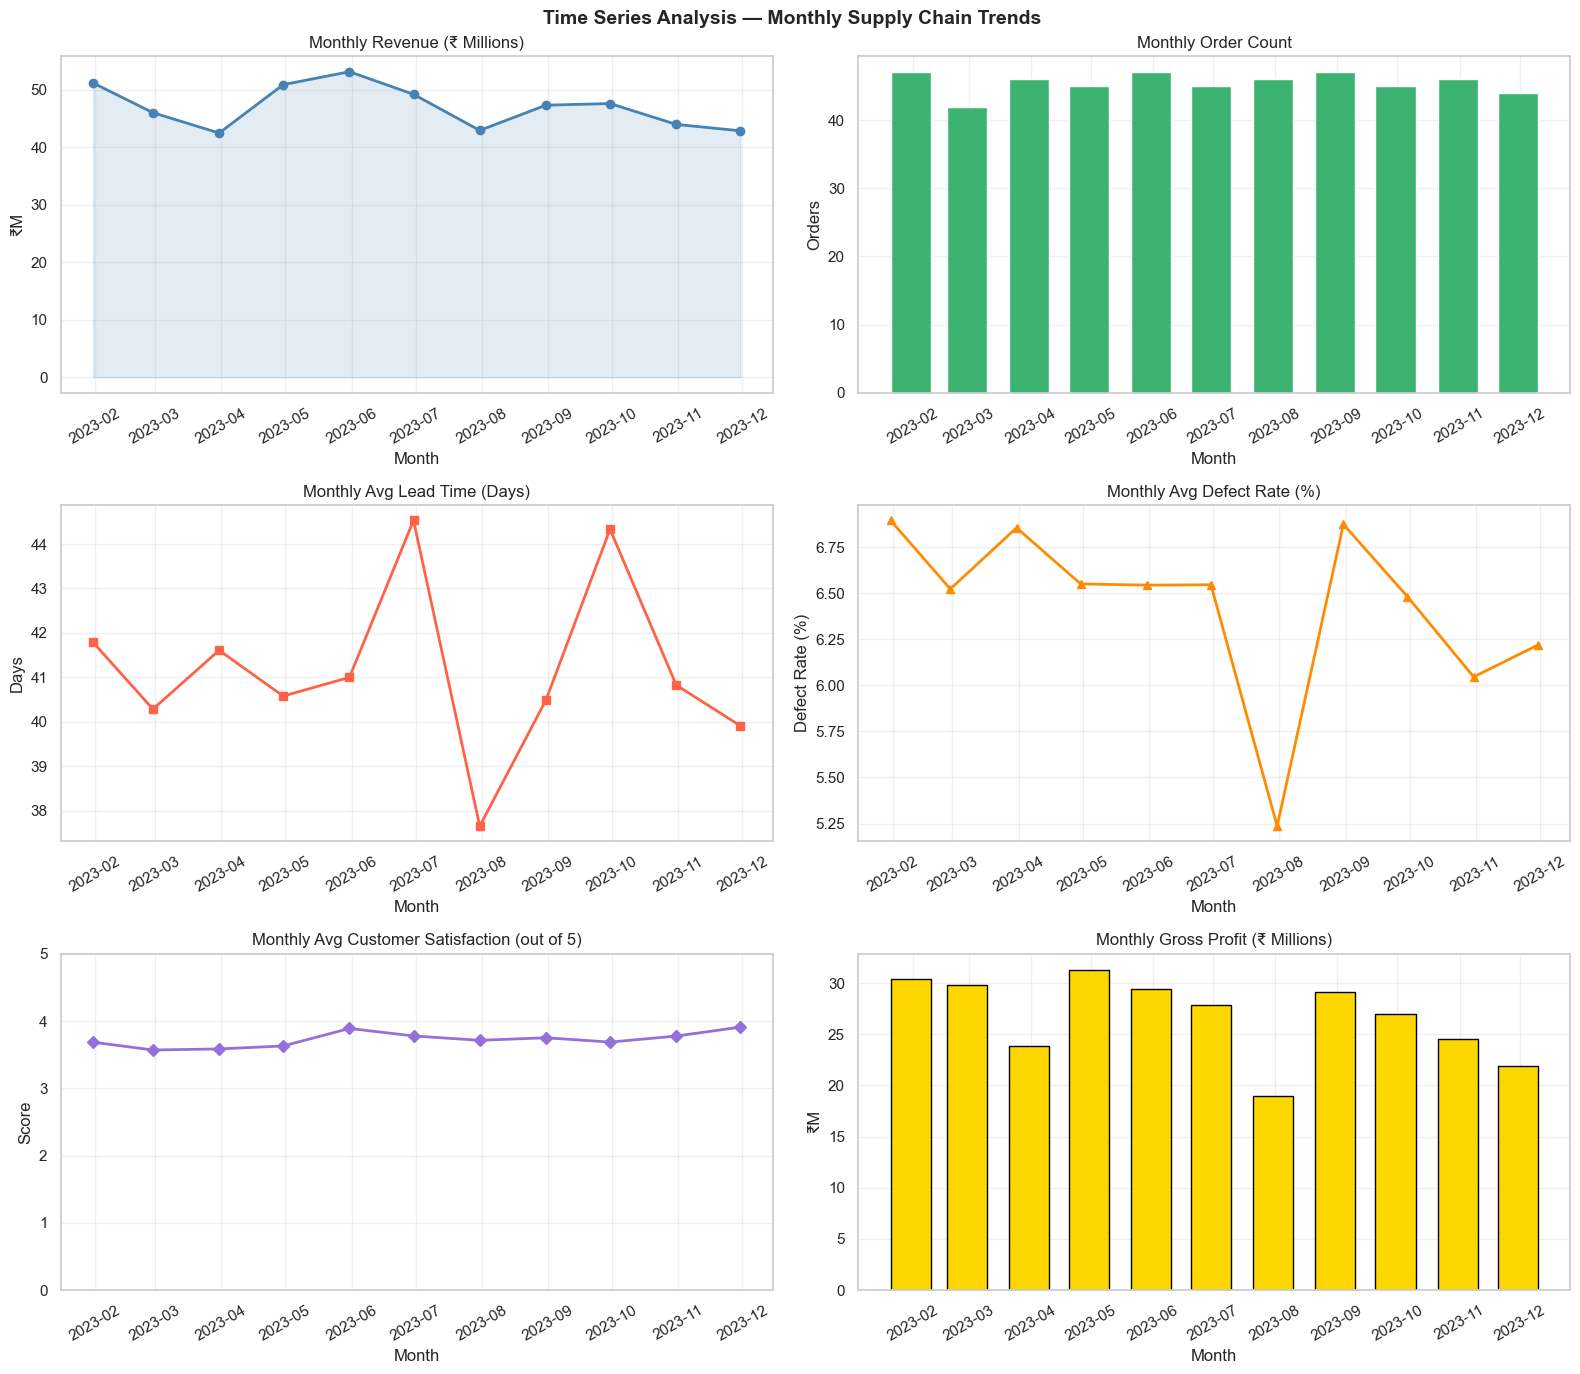

✅ Saved: 08_time_series.png


In [10]:
print("\n" + "="*55)
print("STEP 7 ▸ TIME SERIES ANALYSIS")
print("="*55)
 
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.resample('ME', on='Order Date').agg(
    Total_Revenue    = ('Revenue Generated', 'sum'),
    Total_Orders     = ('Order Quantity',    'count'),
    Avg_Lead_Time    = ('Total Lead Time',   'mean'),
    Avg_Defect_Rate  = ('Defect Rate',       'mean'),
    Avg_Satisfaction = ('Customer Satisfaction', 'mean'),
    Total_Profit     = ('Gross Profit',      'sum'),
).reset_index()
 
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Time Series Analysis — Monthly Supply Chain Trends',
             fontsize=14, fontweight='bold')
 
# Revenue
axes[0,0].plot(monthly['Order Date'], monthly['Total_Revenue']/1e6,
               marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(monthly['Order Date'], monthly['Total_Revenue']/1e6,
                        alpha=0.15, color='steelblue')
axes[0,0].set_title('Monthly Revenue (₹ Millions)')
axes[0,0].set_ylabel('₹M')
 
# Orders
axes[0,1].bar(monthly['Order Date'], monthly['Total_Orders'],
              color='mediumseagreen', width=20)
axes[0,1].set_title('Monthly Order Count')
axes[0,1].set_ylabel('Orders')
 
# Lead Time
axes[1,0].plot(monthly['Order Date'], monthly['Avg_Lead_Time'],
               marker='s', color='tomato', linewidth=2)
axes[1,0].set_title('Monthly Avg Lead Time (Days)')
axes[1,0].set_ylabel('Days')
 
# Defect Rate
axes[1,1].plot(monthly['Order Date'], monthly['Avg_Defect_Rate']*100,
               marker='^', color='darkorange', linewidth=2)
axes[1,1].set_title('Monthly Avg Defect Rate (%)')
axes[1,1].set_ylabel('Defect Rate (%)')
 
# Customer Satisfaction
axes[2,0].plot(monthly['Order Date'], monthly['Avg_Satisfaction'],
               marker='D', color='mediumpurple', linewidth=2)
axes[2,0].set_ylim(0, 5)
axes[2,0].set_title('Monthly Avg Customer Satisfaction (out of 5)')
axes[2,0].set_ylabel('Score')
 
# Monthly Profit
axes[2,1].bar(monthly['Order Date'], monthly['Total_Profit']/1e6,
              color='gold', edgecolor='black', width=20)
axes[2,1].set_title('Monthly Gross Profit (₹ Millions)')
axes[2,1].set_ylabel('₹M')
 
for ax in axes.flatten():
    ax.set_xlabel('Month')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_tick_params(rotation=30)
 
plt.tight_layout()
plt.savefig('08_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 08_time_series.png")

# CELL 10 — MACHINE LEARNING: HIGH RISK DETECTION


STEP 8 ▸ MACHINE LEARNING — HIGH RISK DETECTION
▸ Median Defect Rate   : 0.0673
▸ High Risk Products   : 55 / 500
▸ Risk Distribution    :
High Risk
0    445
1     55
Name: count, dtype: int64

▸ Train : 400 rows | Test : 100 rows

✅ Accuracy : 0.8900

📋 Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.89      1.00      0.94        89
   High Risk       0.00      0.00      0.00        11

    accuracy                           0.89       100
   macro avg       0.45      0.50      0.47       100
weighted avg       0.79      0.89      0.84       100



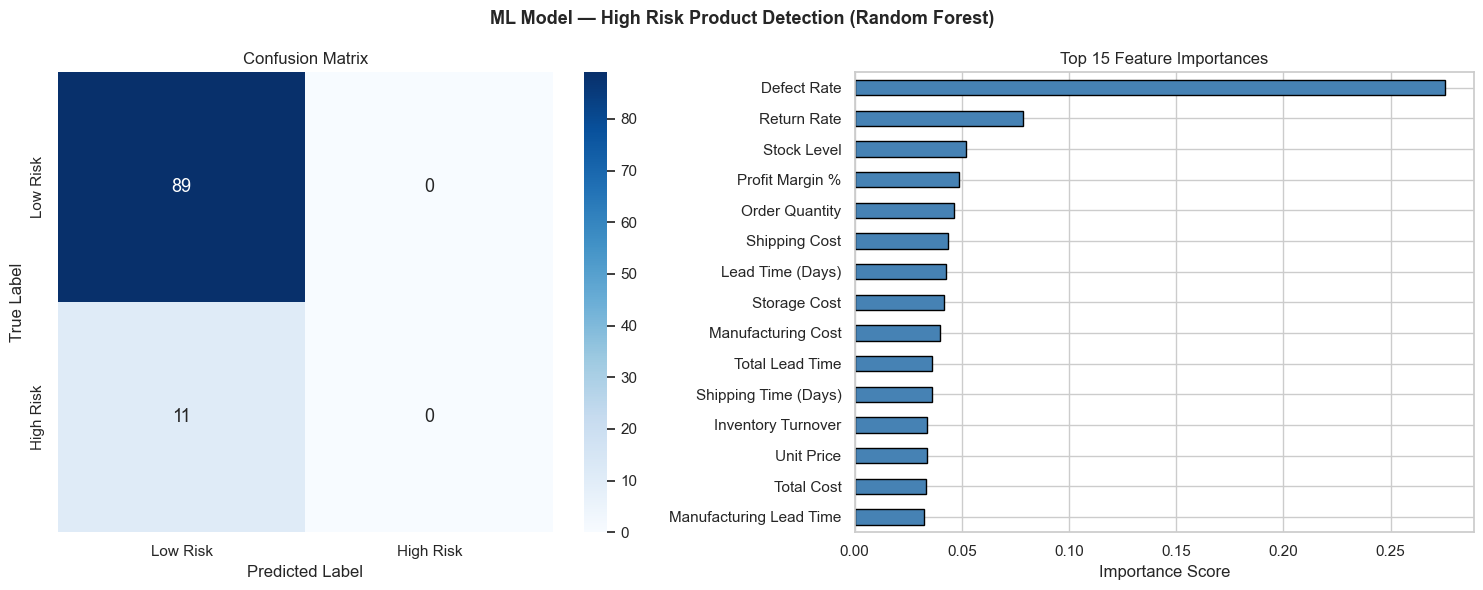

✅ Saved: 09_ml_model.png


In [13]:
print("\n" + "="*55)
print("STEP 8 ▸ MACHINE LEARNING — HIGH RISK DETECTION")
print("="*55)
 
# Target: A product is High Risk if defect rate > median AND inspection failed
median_defect = df['Defect Rate'].median()
df['High Risk'] = (
    (df['Defect Rate'] > median_defect) &
    (df['Inspection Status'] == 'Fail')
).astype(int)
 
print(f"▸ Median Defect Rate   : {median_defect:.4f}")
print(f"▸ High Risk Products   : {df['High Risk'].sum()} / {len(df)}")
print(f"▸ Risk Distribution    :\n{df['High Risk'].value_counts()}")
 
# Encode categoricals
le = LabelEncoder()
ml = df.copy()
cat_cols = ['Product Category', 'Supplier Name', 'Plant Location',
            'Warehouse', 'Transport Mode', 'Order Priority',
            'Inspection Status', 'On Time Delivery']
for c in cat_cols:
    ml[c] = le.fit_transform(ml[c].astype(str))
 
features = ['Product Category', 'Supplier Name', 'Plant Location',
            'Transport Mode', 'Order Priority', 'Order Quantity',
            'Unit Price', 'Manufacturing Cost', 'Shipping Cost',
            'Storage Cost', 'Stock Level', 'Lead Time (Days)',
            'Manufacturing Lead Time', 'Shipping Time (Days)',
            'Production Volume', 'Defect Rate', 'Return Rate',
            'Total Cost', 'Profit Margin %', 'Total Lead Time',
            'Delivery Efficiency', 'Inventory Turnover']
 
X = ml[features]
y = ml['High Risk']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
print(f"\n▸ Train : {X_train.shape[0]} rows | Test : {X_test.shape[0]} rows")
 
rf = RandomForestClassifier(n_estimators=150, random_state=42,
                             class_weight='balanced', max_depth=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
 
print(f"\n✅ Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))
 
# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ML Model — High Risk Product Detection (Random Forest)',
             fontsize=13, fontweight='bold')
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'], ax=axes[0],
            annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
 
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_imp.tail(15).plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 15 Feature Importances')
axes[1].set_xlabel('Importance Score')
 
plt.tight_layout()
plt.savefig('09_ml_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 09_ml_model.png")
 

# CELL 11 — BUSINESS INSIGHTS & RECOMMENDATIONS


In [14]:
print("\n" + "="*60)
print("STEP 9 ▸ BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)
 
top_category   = df.groupby('Product Category')['Revenue Generated'].sum().idxmax()
worst_supplier = df.groupby('Supplier Name')['Defect Rate'].mean().idxmax()
best_supplier  = df.groupby('Supplier Name')['Delivery Efficiency'].mean().idxmax()
slowest_plant  = df.groupby('Plant Location')['Total Lead Time'].mean().idxmax()
costliest_mode = df.groupby('Transport Mode')['Shipping Cost'].mean().idxmax()
high_risk_count= df['High Risk'].sum()
high_risk_pct  = (high_risk_count / len(df) * 100).round(1)
avg_margin     = df['Profit Margin %'].mean().round(1)
avg_defect     = (df['Defect Rate'].mean() * 100).round(2)
avg_lead       = df['Total Lead Time'].mean().round(1)
avg_satisfaction = df['Customer Satisfaction'].mean().round(2)
total_revenue  = df['Revenue Generated'].sum()
total_profit   = df['Gross Profit'].sum()
on_time_pct    = (df['Delivery Efficiency'].mean() * 100).round(1)
 
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MANUFACTURING SUPPLY CHAIN — PERFORMANCE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Revenue          : ₹{total_revenue:,.0f}
  Total Gross Profit     : ₹{total_profit:,.0f}
  Avg Profit Margin      : {avg_margin}%
  Avg Defect Rate        : {avg_defect}%
  Avg Total Lead Time    : {avg_lead} days
  On-Time Delivery Rate  : {on_time_pct}%
  Avg Customer Score     : {avg_satisfaction} / 5.0
  High Risk Products     : {high_risk_count} ({high_risk_pct}% of total)
  Top Revenue Category   : {top_category}
  Best Supplier          : {best_supplier} (highest on-time delivery)
  Worst Supplier         : {worst_supplier} (highest defect rate)
  Slowest Plant          : {slowest_plant}
  Costliest Transport    : {costliest_mode}
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. 📈 Increase production capacity for '{top_category}'
     — it is the highest revenue-generating category.
 
  2. 🔴 Audit '{worst_supplier}' immediately.
     Defect rate is above threshold — enforce SLA or
     switch to alternate supplier.
 
  3. ⏰ '{slowest_plant}' has the longest lead times.
     Investigate process bottlenecks and consider
     buffer stock strategy for this plant.
 
  4. ✈️  '{costliest_mode}' transport is expensive.
     Reserve only for critical/high-priority orders.
     Default to Road/Rail for standard orders.
 
  5. ⚠️  {high_risk_pct}% of products are High Risk.
     Deploy the ML model in production to auto-flag
     these before dispatch — prevents returns and
     customer dissatisfaction.
 
  6. 😊 Customer Satisfaction avg is {avg_satisfaction}/5.
     Improve by reducing defect rates and improving
     on-time delivery (currently {on_time_pct}%).
 
  7. 🤝 Partner more with '{best_supplier}' — best
     on-time delivery performance across all suppliers.
""")
 
print("=" * 60)
print("✅  END-TO-END MANUFACTURING SUPPLY CHAIN ANALYSIS DONE!")
print("=" * 60)


STEP 9 ▸ BUSINESS INSIGHTS & RECOMMENDATIONS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MANUFACTURING SUPPLY CHAIN — PERFORMANCE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Revenue          : ₹517,393,970
  Total Gross Profit     : ₹294,126,686
  Avg Profit Margin      : 17.7%
  Avg Defect Rate        : 6.44%
  Avg Total Lead Time    : 41.2 days
  On-Time Delivery Rate  : 71.8%
  Avg Customer Score     : 3.73 / 5.0
  High Risk Products     : 55 (11.0% of total)
  Top Revenue Category   : Raw Material
  Best Supplier          : Vedanta (highest on-time delivery)
  Worst Supplier         : SAIL (highest defect rate)
  Slowest Plant          : Nagpur Plant
  Costliest Transport    : Rail

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. 📈 Increase production capacity for 'Raw Material'
     — it is the highest revenue-generating category.

  2. 🔴 Audit 'SAIL' immediately.
     Defect